## Regresión Lineal:Coste de incidente de seguridad
En este ejercicio se explicarán los fundamentos básicos de la regresión lineal aplicada a un caso de uso sencillo relacionado con la ciberseguridad.

## Enunciado del ejercicio
Este ejercicio consiste en predecir el costo de un incidente de seguridad en base al número de equipos que se han visto afectados. El conjunto de datos es generado de manera aleatoria.

## Generación del conjunto de datos

In [36]:
import numpy as np
x = 2 * np.random.rand(100, 1)
y = 4 + 3*x + np.random.rand(100, 1)
print("La longitud del conjunto de datos:", len(x))

La longitud del conjunto de datos: 100


## Visualización del conjunto de datos

In [37]:
import matplotlib.pyplot as plt
%matplotlib inline

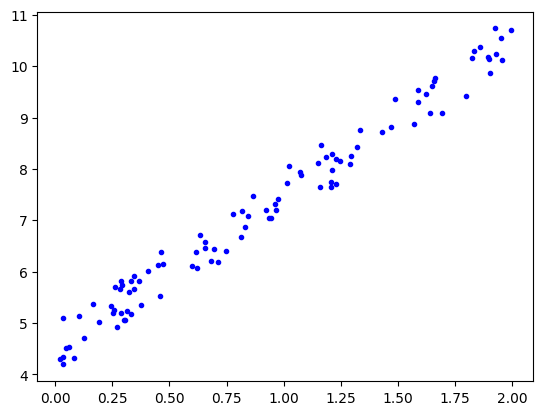

In [38]:
plt.plot(x,y,"b.")
plt.show()

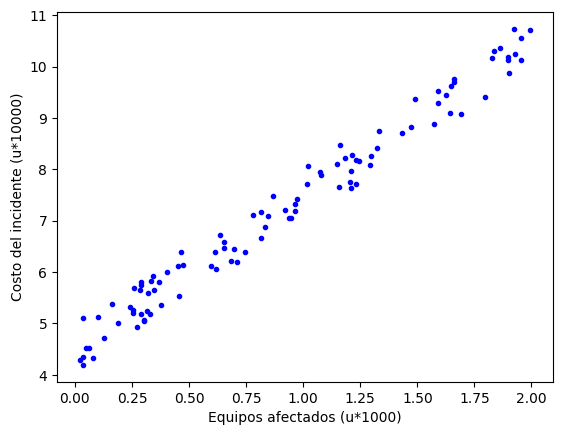

In [44]:
plt.plot(x, y, "b.")
plt.xlabel ("Equipos afectados (u*1000)")
plt.ylabel ("Costo del incidente (u*10000)")
plt.show()

## Modificación del conjunto de datos

In [39]:
import pandas as pd

Convertimos los datos a su valor real, en lugar de usar factores de converción

In [45]:
data = {'n_equipos_afectados': x.flatten(),'costo' : y.flatten()}
df = pd.DataFrame(data)
df.head(10)

,n_equipos_afectados,costo
0,0.285343,5.654316
1,1.208413,7.643104
2,1.296394,8.257737
3,0.684006,6.206156
4,0.291202,5.743198
5,0.035340,5.098244
6,1.625394,9.453230
7,1.230183,8.187505
8,0.404042,6.007846
9,1.183625,8.225121


In [46]:
# Escalado de número de equipos afectados a un valor má real
df['n_equipos_afectados'] = df ['n_equipos_afectados'] * 1000
df['n_equipos_afectados'] = df['n_equipos_afectados'].astype('int')
# Escalado de costo a un valor má real
df['costo'] = df['costo'] * 10000
df['costo'] = df['costo'].astype('int')
df.head(10)

,n_equipos_afectados,costo
0,285,56543
1,1208,76431
2,1296,82577
3,684,62061
4,291,57431
5,35,50982
6,1625,94532
7,1230,81875
8,404,60078
9,1183,82251


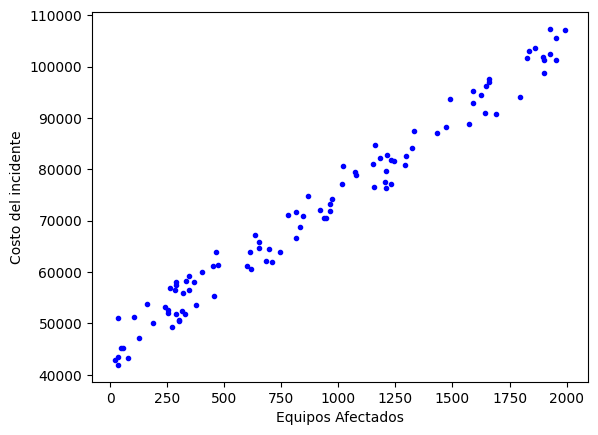

In [47]:
#Reepresentación gráfica de conjunto de datos
plt.plot(df['n_equipos_afectados'], df ['costo'], "b.")
plt.xlabel("Equipos Afectados")
plt.ylabel("Costo del incidente")
plt.show()

## Construcción del modelo

In [48]:
from sklearn.linear_model import LinearRegression

In [53]:
# carga delm modelo y ajuste de la función hipótesis
lin_reg = LinearRegression()
lin_reg.fit (df['n_equipos_afectados'].values.reshape(-1,1), df['costo'].values)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [54]:
# Muestra el valor que se le asigó al parámetro Theta0
lin_reg.intercept_

np.float64(44933.23323169816)

In [55]:
#Muestra el valor que se le asignó al parametro theta (pendiente que tendrá le modelo de regresión lineal)
lin_reg.coef_

array([30.06812183])

### Predicción para el valor mínimo y máximo del conjunto de datos de entrenamiento

In [56]:
x_min_max = np.array([[df['n_equipos_afectados'].min()],[df['n_equipos_afectados'].max()]])
y_train_pred = lin_reg.predict(x_min_max)

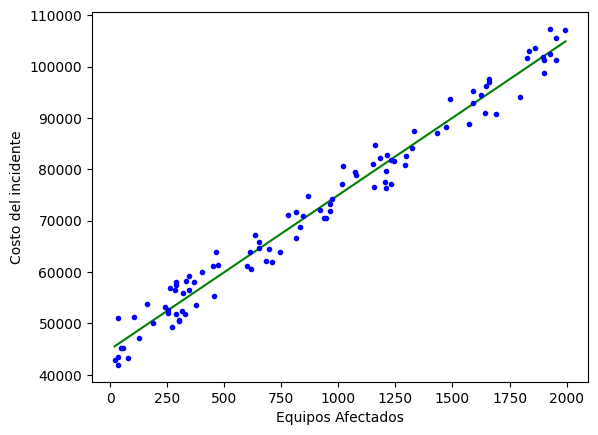

In [60]:
# Representación gráfica de la función de hipotesis generada
plt.plot(x_min_max, y_train_pred, "g-")
plt.plot(df['n_equipos_afectados'], df ['costo'], "b.")
plt.xlabel("Equipos Afectados")
plt.ylabel("Costo del incidente")
plt.show()

### Predicción de nuevos ejemplos

In [66]:
x_new = np.array([[1252]])
#Predicción del costo que tendria este incidente
costo= lin_reg.predict(x_new)
print('El costo del incidente sería:', int(costo[0]), '$')

El costo del incidente sería: 82578 $


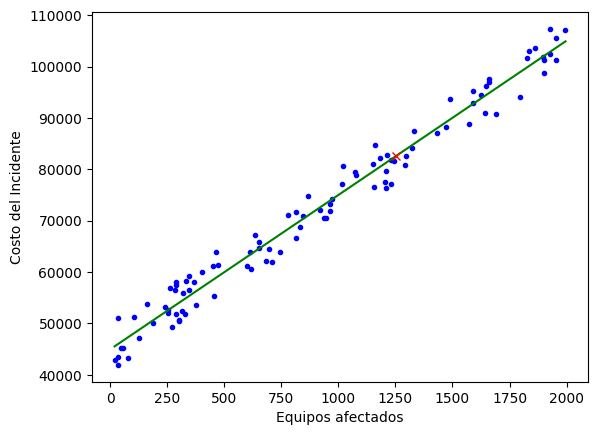

In [67]:
plt.plot(df['n_equipos_afectados'], df['costo'], "b.")
plt.plot(x_min_max, y_train_pred, "g-")
plt.plot(x_new, costo, "rx")
plt.xlabel("Equipos afectados")
plt.ylabel("Costo del Incidente")
plt.show()